Train accuracy: 0.976  |  Classes: [np.str_('EV'), np.str_('Hybrid/Other'), np.str_('ICE (Diesel)'), np.str_('ICE (Gas)')]
Saved: svc_decision_boundary.png


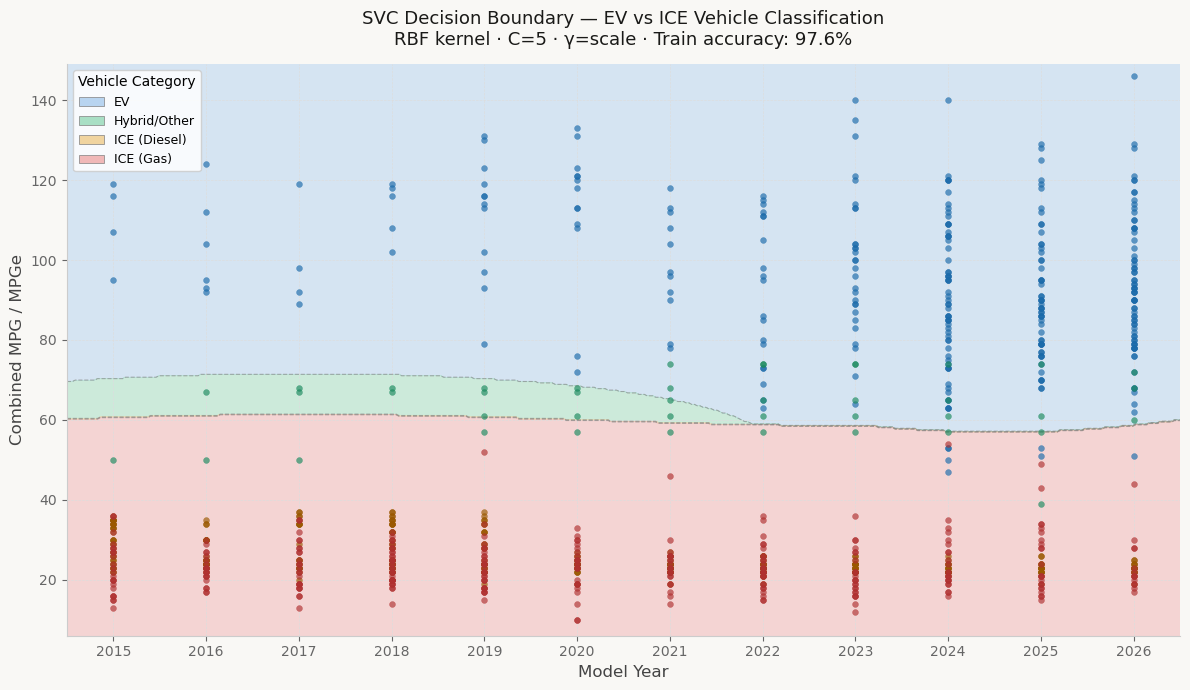

In [3]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
import random

# ── Load data ──────────────────────────────────────────────────────────────
import os

CSV_PATH = os.path.expanduser("~/Downloads/EV_vs_ICE_Vehicle_Specs_2015_2026.csv")

if not os.path.exists(CSV_PATH):
    # Running in Jupyter? Use a file chooser
    try:
        import ipywidgets as widgets
        from IPython.display import display
        uploader = widgets.FileUpload(accept=".csv", multiple=False)
        display(uploader)
        print("Upload your CSV above, then re-run this cell.")
        raise SystemExit
    except ImportError:
        raise FileNotFoundError(
            f"Could not find '{CSV_PATH}'. "
            "Set CSV_PATH to the full path of your file."
        )

with open(CSV_PATH) as f:
    rows = list(csv.DictReader(f))

cats_keep = {"EV", "ICE (Gas)", "ICE (Diesel)", "Hybrid/Other"}
data = [
    (float(r["Combined_MPG"]), int(r["Year"]), r["Vehicle_Category"].strip())
    for r in rows
    if r["Vehicle_Category"].strip() in cats_keep
]

X = np.array([[d[0], d[1]] for d in data])   # [MPG, Year]
y_raw = [d[2] for d in data]

le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_                          # alphabetical order

# ── Fit SVC ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svc = SVC(kernel="rbf", C=5, gamma="scale")
svc.fit(X_scaled, y)

acc = accuracy_score(y, svc.predict(X_scaled))
print(f"Train accuracy: {acc:.3f}  |  Classes: {list(classes)}")

# ── Build decision mesh ────────────────────────────────────────────────────
mpg_min, mpg_max = X[:, 0].min() - 3,  X[:, 0].max() + 3
yr_min,  yr_max  = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx_mpg, xx_yr = np.meshgrid(
    np.linspace(mpg_min, mpg_max, 400),
    np.linspace(yr_min,  yr_max,  400),
)
mesh_pts = np.c_[xx_mpg.ravel(), xx_yr.ravel()]
Z = svc.predict(scaler.transform(mesh_pts)).reshape(xx_mpg.shape)

# ── Colors ─────────────────────────────────────────────────────────────────
# Order matches le.classes_: EV, Hybrid/Other, ICE (Diesel), ICE (Gas)
region_colors = ["#b8d4f0", "#a8dfc5", "#f0d4a0", "#f0b8b8"]
dot_colors    = ["#1a6aaa", "#1a8a5e", "#9a5800", "#b03030"]

region_cmap = ListedColormap(region_colors)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#f9f8f5")
ax.set_facecolor("#f9f8f5")

# Decision regions
ax.contourf(xx_yr, xx_mpg, Z, levels=np.arange(-0.5, len(classes), 1),
            cmap=region_cmap, alpha=0.55, zorder=1)

# Decision boundary lines
ax.contour(xx_yr, xx_mpg, Z, levels=np.arange(0.5, len(classes), 1),
           colors="gray", linewidths=0.8, linestyles="--", alpha=0.6, zorder=2)

# Scatter points (sample for clarity)
random.seed(42)
for i, cat in enumerate(classes):
    idx = [j for j, c in enumerate(y_raw) if c == cat]
    sampled = random.sample(idx, min(300, len(idx)))
    ax.scatter(
        X[sampled, 1], X[sampled, 0],
        c=dot_colors[i], s=18, alpha=0.65,
        edgecolors=dot_colors[i], linewidths=0.3,
        zorder=3, label=cat
    )

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_xlabel("Model Year", fontsize=12, color="#444")
ax.set_ylabel("Combined MPG / MPGe", fontsize=12, color="#444")
ax.set_title(
    f"SVC Decision Boundary — EV vs ICE Vehicle Classification\n"
    f"RBF kernel · C=5 · γ=scale · Train accuracy: {acc*100:.1f}%",
    fontsize=13, fontweight="normal", color="#1a1a18", pad=14
)

ax.set_xlim(yr_min, yr_max)
ax.set_ylim(mpg_min, mpg_max)
ax.set_xticks(range(2015, 2027))
ax.tick_params(colors="#666", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ccc")
ax.grid(color="#ddd", linewidth=0.5, linestyle="--", zorder=0)

# Legend: region patches + dot markers combined
region_patches = [
    mpatches.Patch(facecolor=region_colors[i], edgecolor="gray",
                   linewidth=0.5, label=classes[i])
    for i in range(len(classes))
]
ax.legend(
    handles=region_patches,
    title="Vehicle Category", title_fontsize=10,
    fontsize=9, framealpha=0.85, edgecolor="#ccc",
    loc="upper left"
)

plt.tight_layout()
plt.savefig("svc_decision_boundary.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved: svc_decision_boundary.png")
plt.show()